# Forecasting power demand in Lithuania

Data is available [here](https://data.gov.lt/datasets/2903/?resource_version=705).

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [92]:
data = pd.read_csv('./data/vartojimas-203.csv',
                   engine='pyarrow',
                   parse_dates=['utc'])

In [93]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 27361 entries, 0 to 27360
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   id      27361 non-null  int64        
 1   value   27361 non-null  float64      
 2   ltu     27361 non-null  datetime64[s]
 3   utc     27361 non-null  datetime64[s]
dtypes: datetime64[s](2), float64(1), int64(1)
memory usage: 855.2 KB


In [94]:
data.head()

,id,value,ltu,utc
0,203,978.868,2023-01-01 02:00:00,2023-01-01 00:00:00
1,203,947.675,2023-01-01 03:00:00,2023-01-01 01:00:00
2,203,937.409,2023-01-01 04:00:00,2023-01-01 02:00:00
3,203,933.605,2023-01-01 05:00:00,2023-01-01 03:00:00
4,203,961.825,2023-01-01 06:00:00,2023-01-01 04:00:00


In [95]:
data = data.drop(columns='id')

In [113]:
data = data.rename(columns={'ltu':'time_lt',
                            'utc':'time_utc'})

In [114]:
data

,value,time_lt,time_utc,date
0,978.868,2023-01-01 02:00:00,2023-01-01 00:00:00,2023-01-01
1,947.675,2023-01-01 03:00:00,2023-01-01 01:00:00,2023-01-01
2,937.409,2023-01-01 04:00:00,2023-01-01 02:00:00,2023-01-01
3,933.605,2023-01-01 05:00:00,2023-01-01 03:00:00,2023-01-01
4,961.825,2023-01-01 06:00:00,2023-01-01 04:00:00,2023-01-01
...,...,...,...,...
27356,1741.394,2026-02-13 22:00:00,2026-02-13 20:00:00,2026-02-13
27357,1643.696,2026-02-13 23:00:00,2026-02-13 21:00:00,2026-02-13
27358,1574.306,2026-02-14 00:00:00,2026-02-13 22:00:00,2026-02-13
27359,1533.344,2026-02-14 01:00:00,2026-02-13 23:00:00,2026-02-13


In [115]:
data[data.value == 0]

,value,time_lt,time_utc,date


<Axes: xlabel='time_lt'>

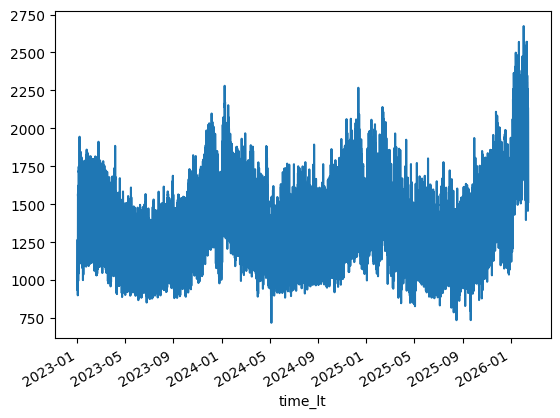

In [117]:
data.plot(x='time_lt',
          y='value',
          legend=False)

In [118]:
data.value.isna().sum()

np.int64(0)

<Axes: xlabel='time_lt'>

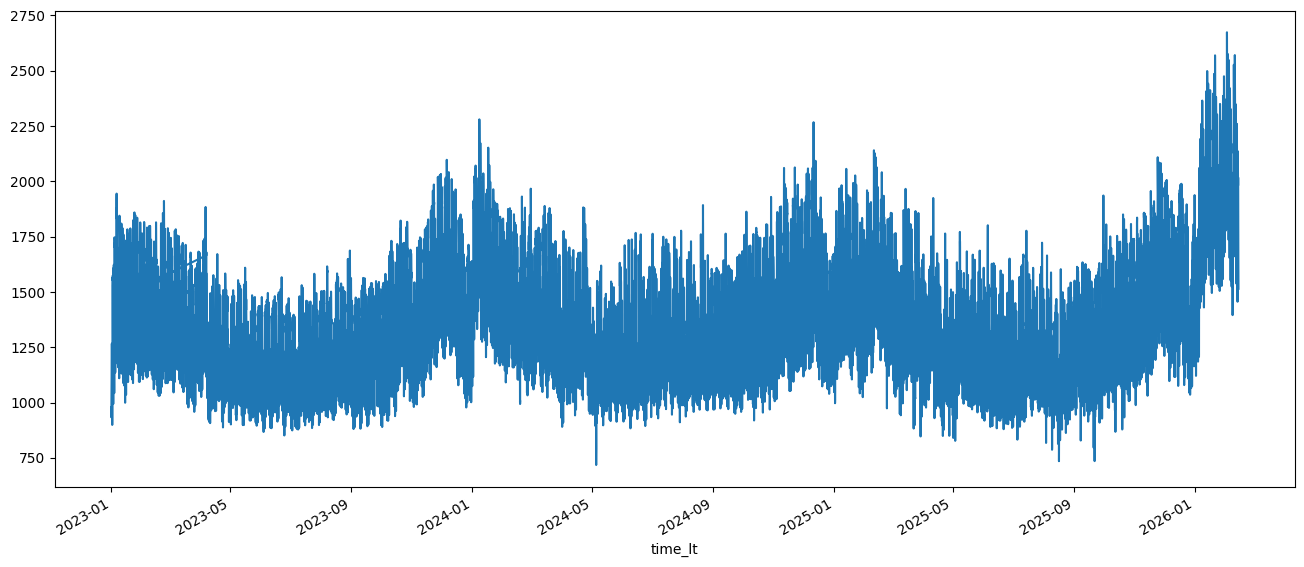

In [119]:
fig, ax = plt.subplots(1, 1, figsize=(16, 7))

data.plot(x='time_lt',
          y='value',
          legend=False,
          ax=ax)

In [121]:
data['date'] = data['time_lt'].dt.date

<Axes: xlabel='date'>

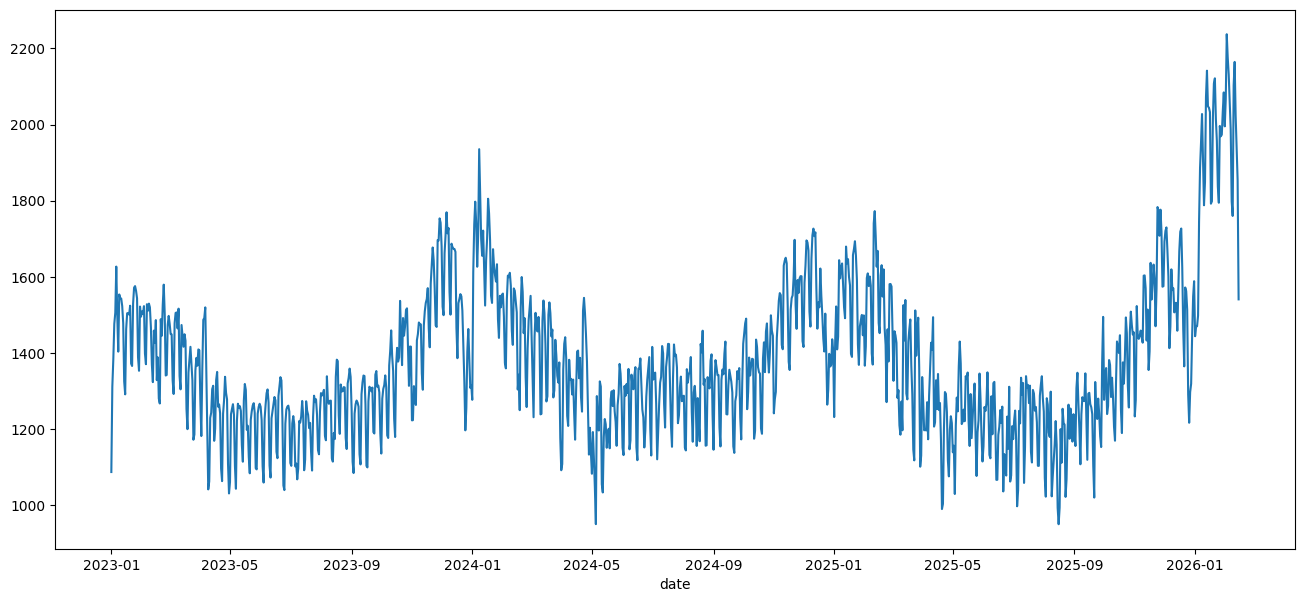

In [122]:
fig, ax = plt.subplots(1, 1, figsize=(16, 7))

data.groupby('date')['value'].mean().plot(ax=ax)